# 15회차 — 기상 변수 탐색

전 생애 더위 노출(THI 비율)이 한우 등급·가격과
어떻게 연관되는지 그림으로 확인한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal
import platform, os
import warnings
warnings.filterwarnings("ignore")

def set_korean_font():
    system = platform.system()
    if system == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    elif system == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

sns.set_style("whitegrid")   # ※ set_style이 font.family를 덮어쓰므로 폰트보다 먼저 호출
set_korean_font()
os.makedirs("../../figures", exist_ok=True)

In [2]:
df = pd.read_csv("../../data/processed/3_eda/step8_scatter.csv",
                 encoding="utf-8-sig", low_memory=False)
for c in ["ABATT_DATE","BIRTH_YMD","JUDGE_DATE"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
if "grade_num" not in df.columns:
    grade_map = {"1++A":15,"1++B":14,"1++C":13,"1+A":12,"1+B":11,"1+C":10,
                 "1A":9,"1B":8,"1C":7,"2A":6,"2B":5,"2C":4,"3A":3,"3B":2,"3C":1,"등외":0}
    df["grade_num"] = df["LAST_GRADE"].map(grade_map)

grade_order = ["1++A","1++B","1++C","1+A","1+B","1+C",
               "1A","1B","1C","2A","2B","2C","3A","3B","3C","등외"]
grade_order = [g for g in grade_order if g in df["LAST_GRADE"].unique()]

# 더위 노출 비율 (전 생애)
df["ratio_고온"]   = (df["days_주의"]+df["days_경고"]+df["days_위험"]) / df["days_total"]
df["ratio_강더위"] = (df["days_경고"]+df["days_위험"]) / df["days_total"]
df["ratio_위험"]   = df["days_위험"] / df["days_total"]

print(f"데이터: {df.shape}")
print(df[["ratio_고온","ratio_강더위","ratio_위험"]].describe().round(3))

데이터: (2408699, 49)
          ratio_고온    ratio_강더위     ratio_위험
count  2408699.000  2408699.000  2408699.000
mean         0.415        0.274        0.032
std          0.050        0.048        0.023
min          0.000        0.000        0.000
25%          0.382        0.242        0.015
50%          0.414        0.274        0.028
75%          0.449        0.306        0.046
max          1.000        1.000        0.333


## 1. 등급별 고온노출 비율

좋은 등급(1++)이 낮고 나쁜 등급(3C·등외)이 높으면 더위 영향 가설 지지.

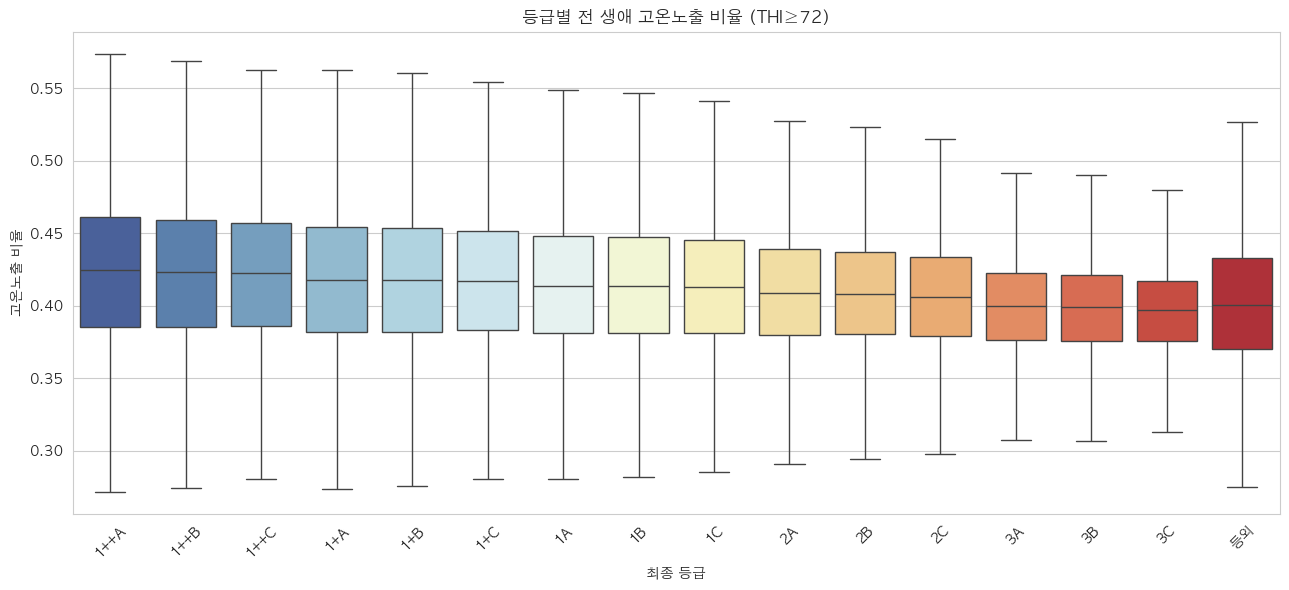

등급별 평균 고온노출 비율:
LAST_GRADE
1++A    0.422
1++B    0.421
1++C    0.421
1+A     0.417
1+B     0.417
1+C     0.417
1A      0.414
1B      0.414
1C      0.413
2A      0.409
2B      0.409
2C      0.406
3A      0.399
3B      0.397
3C      0.395
등외      0.401
Name: ratio_고온, dtype: float64


In [3]:
plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x="LAST_GRADE", y="ratio_고온", order=grade_order,
            hue="LAST_GRADE", hue_order=grade_order, palette="RdYlBu_r",
            legend=False, showfliers=False)
plt.title("등급별 전 생애 고온노출 비율 (THI≥72)")
plt.xlabel("최종 등급"); plt.ylabel("고온노출 비율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../figures/15_ratio_by_grade.png", dpi=100, bbox_inches="tight")
plt.show()

print("등급별 평균 고온노출 비율:")
print(df.groupby("LAST_GRADE")["ratio_고온"].mean().reindex(grade_order).round(3))

## 2. 고온노출 vs 가격 (수익성)

COST_AMT는 결측 37%라 가격 있는 행만 그려짐.

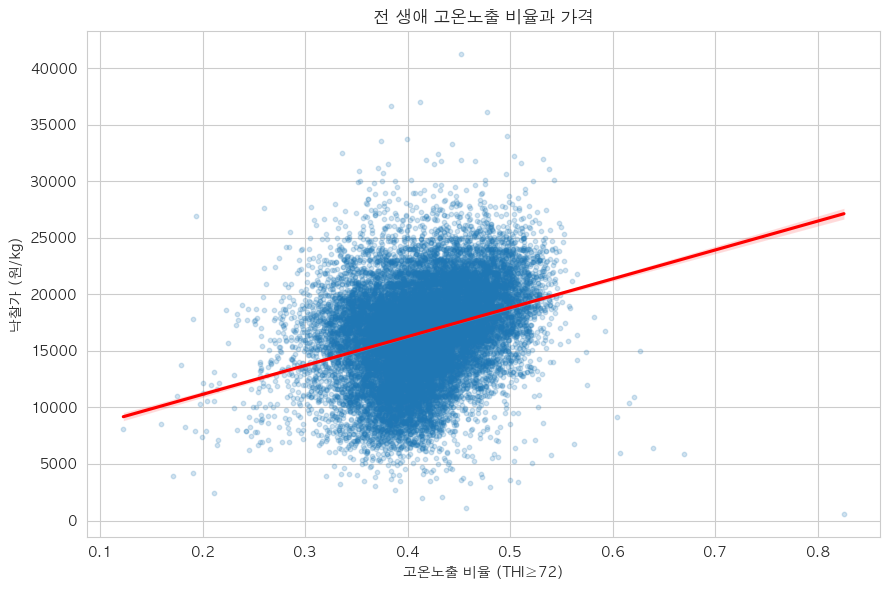

고온노출 비율 × 가격 상관: r = +0.300


In [4]:
df_price = df[df["COST_AMT"].notnull()]
df_sample = df_price.sample(n=min(20000, len(df_price)), random_state=42)
plt.figure(figsize=(9, 6))
sns.regplot(data=df_sample, x="ratio_고온", y="COST_AMT",
            scatter_kws={"alpha":0.2,"s":10}, line_kws={"color":"red"})
plt.title("전 생애 고온노출 비율과 가격")
plt.xlabel("고온노출 비율 (THI≥72)"); plt.ylabel("낙찰가 (원/kg)")
plt.tight_layout()
plt.savefig("../../figures/15_ratio_vs_cost.png", dpi=100, bbox_inches="tight")
plt.show()
r = df_price[["ratio_고온","COST_AMT"]].corr().iloc[0, 1]
print(f"고온노출 비율 × 가격 상관: r = {r:+.3f}")

## 3. 출생 계절별 등급 (장기 영향)

여름에 태어난 송아지가 평생 등급이 낮은지.

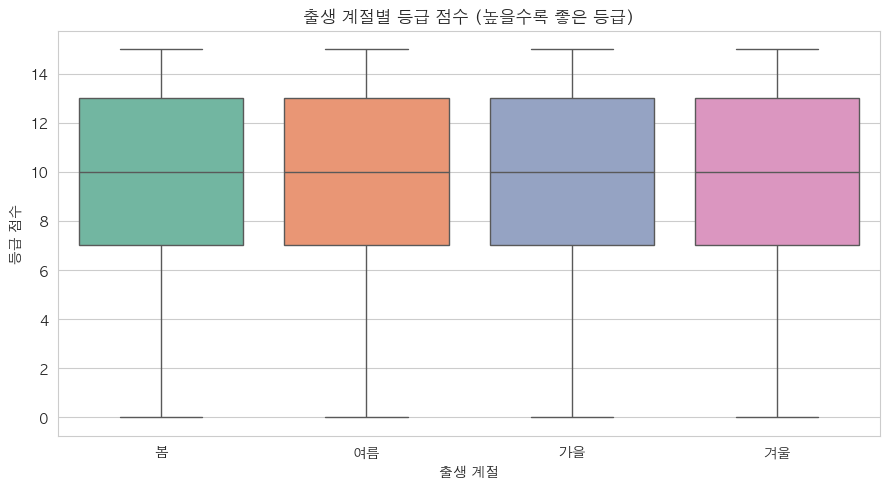

출생 계절별 등급 Kruskal-Wallis: H=610.4, p=5.686e-132


In [5]:
month_to_season = {12:"겨울",1:"겨울",2:"겨울", 3:"봄",4:"봄",5:"봄",
                   6:"여름",7:"여름",8:"여름", 9:"가을",10:"가을",11:"가을"}
df["birth_season"] = df["BIRTH_YMD"].dt.month.map(month_to_season)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="birth_season", y="grade_num", order=["봄","여름","가을","겨울"],
            hue="birth_season", hue_order=["봄","여름","가을","겨울"],
            palette="Set2", legend=False, showfliers=False)
plt.title("출생 계절별 등급 점수 (높을수록 좋은 등급)")
plt.xlabel("출생 계절"); plt.ylabel("등급 점수")
plt.tight_layout()
plt.savefig("../../figures/15_birth_season.png", dpi=100, bbox_inches="tight")
plt.show()

groups = [df[df["birth_season"]==s]["grade_num"].dropna()
          for s in ["봄","여름","가을","겨울"]]
h, p = kruskal(*groups)
print(f"출생 계절별 등급 Kruskal-Wallis: H={h:.1f}, p={p:.4g}")

## 4. 고온노출 구간별 평균 등급 (핵심)

더위 노출을 4구간으로 나눠 평균 등급이 떨어지는 추세가 있는지 본다.
※ qcut에 duplicates="drop" — 더위 0인 소가 많아 구간 경계가 겹쳐도 안전.

           mean_grade       n  std_grade
고온_bin                                  
낮음(하위25%)       9.313  602180      3.865
중하              8.889  602186      3.935
중상              9.542  602162      3.773
높음(상위25%)      10.568  602171      3.367


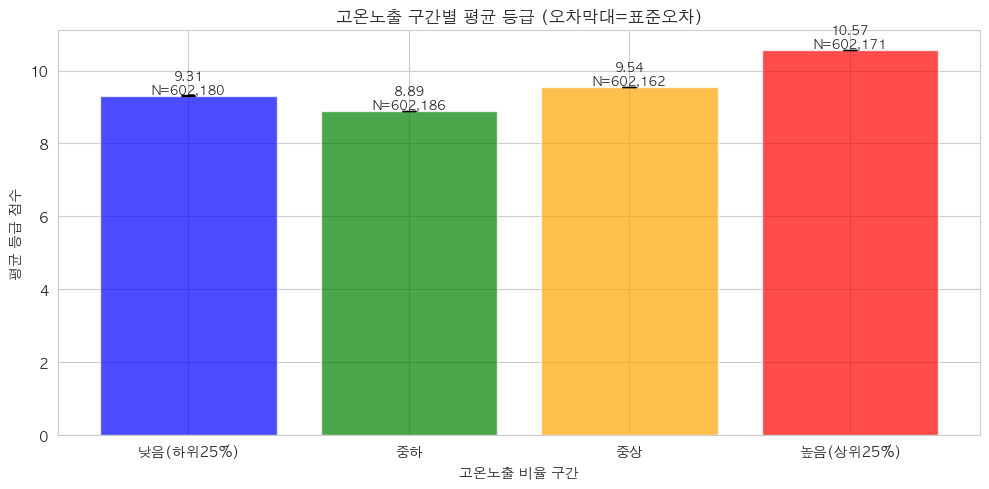

In [6]:
# 비율을 4구간으로 (duplicates="drop"으로 경계 중복 방어)
df["고온_bin"] = pd.qcut(df["ratio_고온"], q=4,
                        labels=["낮음(하위25%)","중하","중상","높음(상위25%)"],
                        duplicates="drop")

bin_grade = df.groupby("고온_bin", observed=True).agg(
    mean_grade=("grade_num","mean"),
    n=("grade_num","count"),
    std_grade=("grade_num","std")
).round(3)
print(bin_grade)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(bin_grade))
ax.bar(x, bin_grade["mean_grade"],
       yerr=bin_grade["std_grade"]/np.sqrt(bin_grade["n"]),
       color=["blue","green","orange","red"][:len(bin_grade)],
       alpha=0.7, capsize=5)
ax.set_xticks(x); ax.set_xticklabels(bin_grade.index)
ax.set_xlabel("고온노출 비율 구간"); ax.set_ylabel("평균 등급 점수")
ax.set_title("고온노출 구간별 평균 등급 (오차막대=표준오차)")
for i, (idx, row) in enumerate(bin_grade.iterrows()):
    ax.annotate(f"{row['mean_grade']:.2f}\nN={int(row['n']):,}",
                (i, row["mean_grade"]), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../../figures/15_bin_grade.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. 시도별 더위-등급 관계

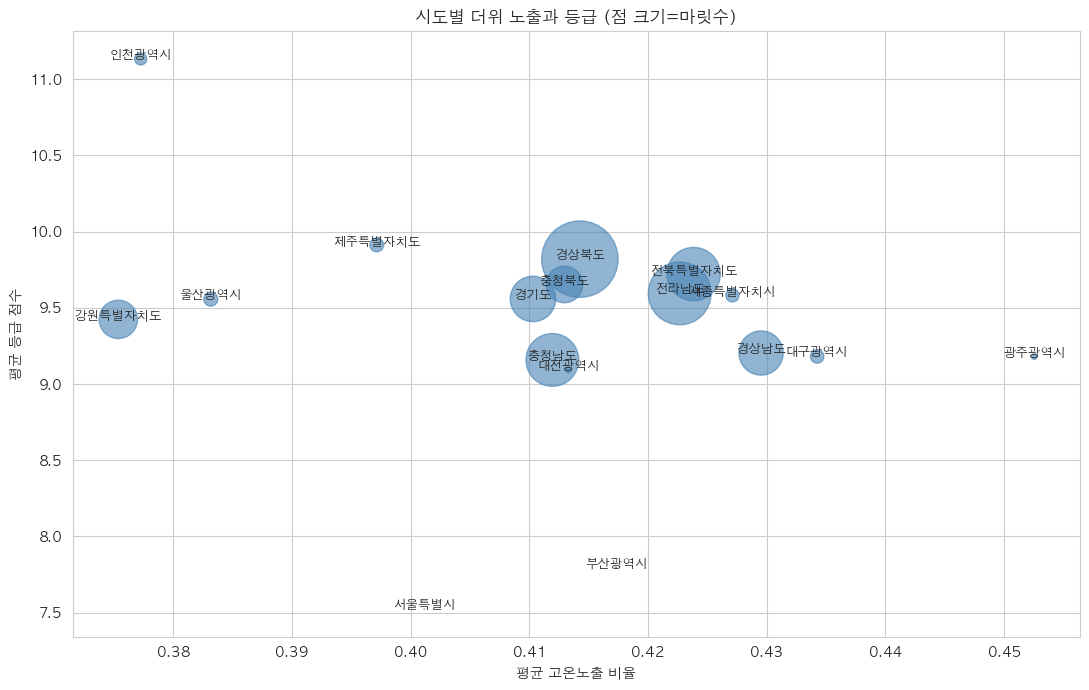

In [7]:
sido_stats = df.groupby("sido").agg(
    mean_heat=("ratio_고온","mean"),
    mean_grade=("grade_num","mean"),
    n=("CATTLE_NO","count")
).reset_index()
plt.figure(figsize=(11, 7))
plt.scatter(sido_stats["mean_heat"], sido_stats["mean_grade"],
            s=sido_stats["n"]/200, alpha=0.6, color="steelblue")
for _, row in sido_stats.iterrows():
    plt.annotate(row["sido"], (row["mean_heat"], row["mean_grade"]),
                 fontsize=9, ha="center")
plt.xlabel("평균 고온노출 비율"); plt.ylabel("평균 등급 점수")
plt.title("시도별 더위 노출과 등급 (점 크기=마릿수)")
plt.tight_layout()
plt.savefig("../../figures/15_sido_heat_grade.png", dpi=100, bbox_inches="tight")
plt.show()

## 6. 정량 검정 — 더위 많이/적게 그룹 등급 차이

In [8]:
q25 = df["ratio_고온"].quantile(0.25)
q75 = df["ratio_고온"].quantile(0.75)
low_heat = df[df["ratio_고온"] <= q25]["grade_num"].dropna()
high_heat = df[df["ratio_고온"] >= q75]["grade_num"].dropna()
print(f"더위 적음(하위25%): N={len(low_heat):,}, 평균 등급={low_heat.mean():.3f}")
print(f"더위 많음(상위25%): N={len(high_heat):,}, 평균 등급={high_heat.mean():.3f}")
u, p = mannwhitneyu(low_heat, high_heat, alternative="two-sided")
print(f"\nMann-Whitney U: p={p:.4g}")
print(f"  → {'더위 노출에 따른 등급 차이 유의' if p < 0.05 else '유의하지 않음'}")

더위 적음(하위25%): N=602,180, 평균 등급=9.313
더위 많음(상위25%): N=602,239, 평균 등급=10.568

Mann-Whitney U: p=0
  → 더위 노출에 따른 등급 차이 유의


## 7. 저장 (더위 비율 변수 추가됨)

In [9]:
df.to_csv("../../data/processed/3_eda/step9_weather.csv",
          index=False, encoding="utf-8-sig")
print(f"저장 완료: step9_weather.csv {df.shape}")
print("추가 컬럼: ratio_고온, ratio_강더위, ratio_위험, birth_season, 고온_bin")

저장 완료: step9_weather.csv (2408699, 51)
추가 컬럼: ratio_고온, ratio_강더위, ratio_위험, birth_season, 고온_bin
